ProBlem 1

We are going to use different variants of regressors to model a sinusoidal function. Use the following code
to create a set of non-linear data:

In [1]:
import numpy as np
np.random.seed(42)
m = 1000
X = 5 * np.random.rand(m, 1) - 2.5
y = np.sin(X)*100 + np.random.randn(m, 1)


1) Apply standardization to the data and plot the learning curve for Linear Regression.

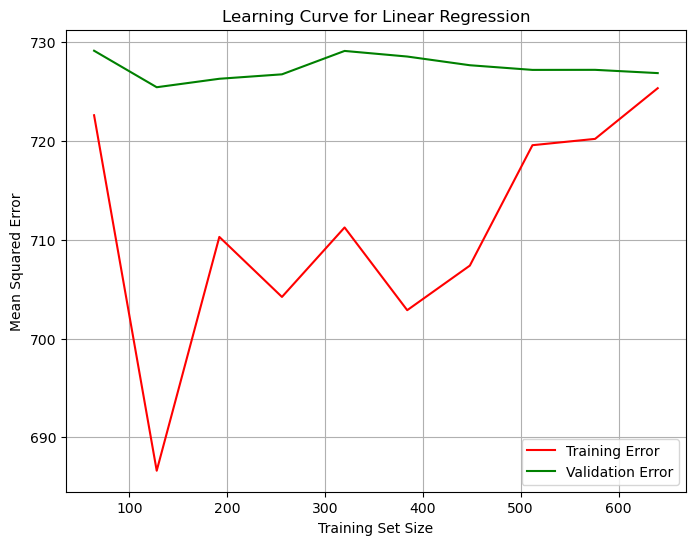

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve, train_test_split

from sklearn.preprocessing import StandardScaler
# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Create and train a Linear Regression model
model = LinearRegression()

#  plot function
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y.ravel(), cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10)
    )
    train_errors = -train_scores.mean(axis=1)
    test_errors = -test_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_errors, label="Training Error", color="red")
    plt.plot(train_sizes, test_errors, label="Validation Error", color="green")
    plt.title("Learning Curve for Linear Regression")
    plt.xlabel("Training Set Size")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid()
    plt.show()

# Plot the learning curve
plot_learning_curve(model, X_train, y_train)

2) Transform the data into a polynomial of degree 50, apply standardization and plot the learning curve.

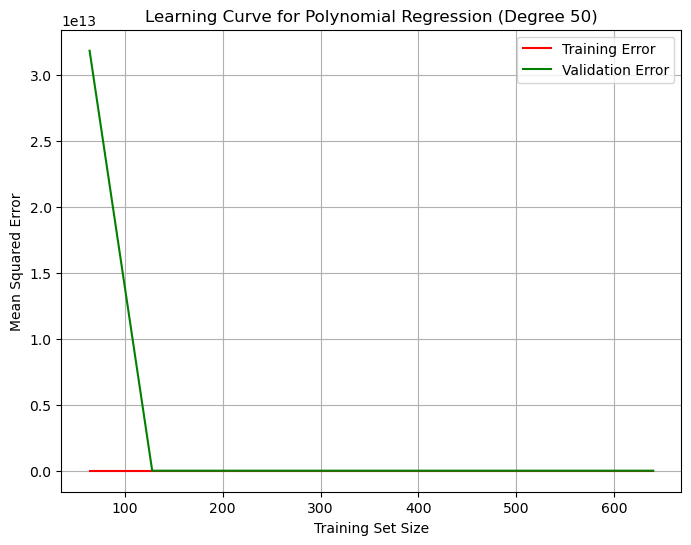

In [7]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler


# Polynomial Transformation
poly = PolynomialFeatures(degree=50, include_bias=False)
X_poly = poly.fit_transform(X)

# Standardize the polynomial features
scaler = StandardScaler()
X_poly_standardized = scaler.fit_transform(X_poly)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_poly_standardized, y, test_size=0.2, random_state=42)

# Create and train a Linear Regression model
model = LinearRegression()

# plot function 
def plot_learning_curve(estimator, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y.ravel(), cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10)
    )
    train_errors = -train_scores.mean(axis=1)
    test_errors = -test_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_errors, label="Training Error", color="red")
    plt.plot(train_sizes, test_errors, label="Validation Error", color="green")
    plt.title("Learning Curve for Polynomial Regression (Degree 50)")
    plt.xlabel("Training Set Size")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid()
    plt.show()

# Plot the learning curve
plot_learning_curve(model, X_train, y_train)

3) Repeat the process for a Regularized Linear Regression model using Ridge Regression with alpha=0.001
and comment on the differences between the three plots

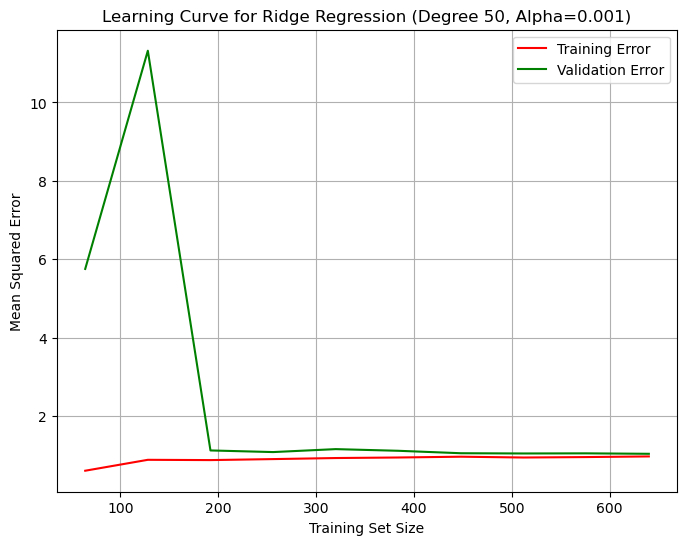

In [15]:
from sklearn.linear_model import Ridge

# Polynomial Transformation
poly = PolynomialFeatures(degree=50, include_bias=False)
X_poly = poly.fit_transform(X)

# Standardize the polynomial features
scaler = StandardScaler()
X_poly_standardized = scaler.fit_transform(X_poly)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_poly_standardized, y, test_size=0.2, random_state=42)

# Create and train a Ridge Regression model
ridge_model = Ridge(alpha=0.001)

# Define a function to plot the learning curve
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y.ravel(), cv=5, scoring="neg_mean_squared_error", train_sizes=np.linspace(0.1, 1.0, 10)
    )
    train_errors = -train_scores.mean(axis=1)
    test_errors = -test_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_errors, label="Training Error", color="red")
    plt.plot(train_sizes, test_errors, label="Validation Error", color="green")
    plt.title(title)
    plt.xlabel("Training Set Size")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.grid()
    plt.show()

# Plot the learning curve for Ridge Regression
plot_learning_curve(ridge_model, X_train, y_train, "Learning Curve for Ridge Regression (Degree 50, Alpha=0.001)")

4) Apply 10-fold cross-validation for the simple Linear Regression model and calculate the mean RMSE
and its standard deviation.

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Create a Linear Regression model
model = LinearRegression()

# Perform 10-fold cross-validation
neg_mse_scores = cross_val_score(model, X, y, cv=10, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-neg_mse_scores)

# Calculate mean RMSE and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

# Print the results
print(f"Mean RMSE: {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Mean RMSE: 27.24
Standard Deviation of RMSE: 1.09


5) Apply 10-fold cross-validation for the polynomial model without regularization and calculate the mean
RMSE.

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score

# Polynomial Transformation
degree = 50
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)


# Standardize the Polynomial Features
scaler = StandardScaler()
X_poly_standardized = scaler.fit_transform(X_poly)

# Create a Linear Regression model (no regularization)
model = LinearRegression()

# Perform 10-fold cross-validation
neg_mse_scores = cross_val_score(model, X_poly_standardized, y, cv=10, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-neg_mse_scores)

# Calculate mean RMSE and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

# Print the results
print(f"Mean RMSE (Polynomial Regression, Degree {degree}): {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")

Mean RMSE (Polynomial Regression, Degree 50): 1.54
Standard Deviation of RMSE: 1.50


6) Apply 10-fold cross-validation for the regularized model and calculate the mean RMSE.

In [22]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score



# Polynomial Transformation
degree = 50
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly.fit_transform(X)

# Standardize the Polynomial Features
scaler = StandardScaler()
X_poly_standardized = scaler.fit_transform(X_poly)

# Create a Ridge Regression model (regularized model)
alpha = 0.001
ridge_model = Ridge(alpha=alpha)

# Step 5: Perform 10-fold cross-validation
neg_mse_scores = cross_val_score(ridge_model, X_poly_standardized, y, cv=10, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-neg_mse_scores)

# Calculate mean RMSE and standard deviation
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

# Print the results
print(f"Mean RMSE (Ridge Regression, Degree {degree}, Alpha {alpha}): {mean_rmse:.2f}")
print(f"Standard Deviation of RMSE: {std_rmse:.2f}")


Mean RMSE (Ridge Regression, Degree 50, Alpha 0.001): 0.99
Standard Deviation of RMSE: 0.06


7) Comment on your results in the queries 4, 5, and 6.

At step 4 the 10-fold cross-validation for the simple Linear Regression model, show us a high RMSE and high Standart deviation. This indicates that the linear regression model struggles to fit the data. The high variance in RMSE across folds shows inconsistency in performance due to the model's inability to capture the data's complexity

At step 5 0-fold cross-validation for the polynomial model without regularization show us lower mean RMSE and higher standart deviation. This imdicates that the model was overfitting the training data because of the high-degree polynomial and lack of regularization. Overfitting causes the model to perform well on some folds but poorly on others.

At step 6 the 10-fold cross-validation for the regularized model show us lower mean RMSE and lower standar deviation from the other models, This indicates that regularization control overfitting and ensures consistent performance across folds